In [2]:
# Install NLTK library
%pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 4.2 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.9 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.9 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.2 MB/s  0:00:01

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   ------------------------ --------------- 3/5 [click]
   ------------------------ --------------- 3/5 [click]
   -------------------------------- ------- 4/5


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [225]:
# Import necessary libraries
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# For image processing
from PIL import Image
import torch
import torchvision.transforms as T
# For text processing
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

Question 1: Food inspection data cleaning 
- 1a. Load food_inspections_practice.csv. Print its dimensions, data types,number of exact duplicate rows and missing/blank values per column. Treat empty strings and whitespace-only values appropriately.

In [226]:
# Load food dataset
food = pd.read_csv('food_inspections_practice.csv')

In [227]:
# Display the first 5 rows of the dataset to see its structure and contents
print("\nFirst 5 rows of the dataset:")
print(food.head(5))

# Print its dimensions
print("\nDimensions of the dataset:", food.shape)


First 5 rows of the dataset:
  Inspection ID   Site ID Inspection Date         DBA Name         AKA Name  \
0     INSP-0001  SITE-001      2025-01-01      river cafe               NaN   
1     INSP-0002  SITE-002      2025-02-04    GARDEN BISTRO    GARDEN BISTRO   
2     INSP-0003  SITE-003      2025-03-07        CITY DELI        CITY DELI   
3     INSP-0004  SITE-004      2025-04-10   OAK RESTAURANT   OAK RESTAURANT   
4     INSP-0005  SITE-005      2025-05-13  HARBOUR KITCHEN  HARBOUR KITCHEN   

  Facility Type         City    Risk  Inspection Score Result  
0          Cafe          NaN     NaN               NaN   FAIL  
1    RESTAURANT       GALWAY     LOW              62.0   PASS  
2    RESTAURANT       DUBLIN  MEDIUM              69.0   PASS  
3    RESTAURANT  LETTERKENNY    HIGH              76.0   PASS  
4    RESTAURANT        SLIGO     LOW              83.0   FAIL  

Dimensions of the dataset: (163, 10)


In [228]:
# Show data types of each column
print("Data types of each column:", "\n",food.dtypes)

Data types of each column: 
 Inspection ID           str
Site ID                 str
Inspection Date         str
DBA Name                str
AKA Name                str
Facility Type           str
City                    str
Risk                    str
Inspection Score    float64
Result                  str
dtype: object


In [229]:
# Count exact duplicate rows
print("\nNumber of exact duplicate rows per column:", food.duplicated().sum())

# Count blank or whitespace-only strings per column
blank_counts = food.apply(
    lambda col: col.map(
        lambda value: isinstance(value, str) and value.strip() == ""
    ).sum()
)

print("Blank values per column:")
print(blank_counts)



Number of exact duplicate rows per column: 3
Blank values per column:
Inspection ID       0
Site ID             0
Inspection Date     0
DBA Name            0
AKA Name            0
Facility Type       0
City                0
Risk                0
Inspection Score    0
Result              0
dtype: int64


In [230]:
# Count missing values per column
print("\nNumber of missing values per column:", "\n", food.isnull().sum())



Number of missing values per column: 
 Inspection ID        0
Site ID              0
Inspection Date      0
DBA Name             0
AKA Name            23
Facility Type        0
City                 9
Risk                13
Inspection Score    14
Result               0
dtype: int64


- 1b. Standardise text case and surrounding whitespace; identify and correct inconsistent 
city spellings; fill missing AKA Name values from DBA Name. Show before/after frequency tables for 
City and missing AKA Name counts.

In [231]:
# To handle missing values, need to choose a treatment based on what the column represents, rather than applying the same method to every column.
# Problem 1: Convert string columns to uppercase
columns_to_upper = [
    'Inspection ID',
    'Site ID',
    'Inspection Date',
    'DBA Name',
    'AKA Name',
    'Facility Type',
    'City',
    'Risk',
    'Result'
]

for col in columns_to_upper:
    food[col] = food[col].str.upper()

print("\nData after converting string columns to uppercase:", "\n", food.head(50))


Data after converting string columns to uppercase: 
    Inspection ID   Site ID Inspection Date         DBA Name         AKA Name  \
0      INSP-0001  SITE-001      2025-01-01      RIVER CAFE               NaN   
1      INSP-0002  SITE-002      2025-02-04    GARDEN BISTRO    GARDEN BISTRO   
2      INSP-0003  SITE-003      2025-03-07        CITY DELI        CITY DELI   
3      INSP-0004  SITE-004      2025-04-10   OAK RESTAURANT   OAK RESTAURANT   
4      INSP-0005  SITE-005      2025-05-13  HARBOUR KITCHEN  HARBOUR KITCHEN   
5      INSP-0006  SITE-006      2025-06-16       MAPLE CAFE       MAPLE CAFE   
6      INSP-0007  SITE-007      2025-07-19   CENTRAL BAKERY   CENTRAL BAKERY   
7      INSP-0008  SITE-008      2025-08-22       PARK GRILL              NaN   
8      INSP-0009  SITE-009      2025-09-25       RIVER CAFE       RIVER CAFE   
9      INSP-0010  SITE-010      2025-10-28    GARDEN BISTRO    GARDEN BISTRO   
10     INSP-0011  SITE-011      2025-11-03        CITY DELI       

In [232]:
# From the missing value result: AKA Name, Risk, City, and Inspection Score have missing values.
# Check the CSV content and replace null value accrodingly
# Find rows with missing values in column
# AKA Name
print("Number of matching rows:", food[food["AKA Name"].isna()].shape[0])
# Print all records 
#missing_aka = food[food["AKA Name"].isna()]
#print(missing_aka.to_string())
#print("Total missing rows:", len(missing_aka))

Number of matching rows: 23


In [233]:
# Replace null values for AKA Names in the 23 rows with DBA Name
food["AKA Name"] = food["AKA Name"].fillna(food["DBA Name"])

# Count missing values after filling
print("After:", food["AKA Name"].isna().sum())

After: 0


In [234]:
# City
print("Number of matching rows:", food[food["City"].isna()].shape[0])
# Print all records 
missing_city = food[food["City"].isna()]
print(missing_city.to_string())
print("Total missing rows:", len(missing_city))

Number of matching rows: 9
    Inspection ID   Site ID Inspection Date         DBA Name         AKA Name Facility Type City    Risk  Inspection Score Result
0       INSP-0001  SITE-001      2025-01-01      RIVER CAFE       RIVER CAFE           CAFE  NaN     NaN               NaN   FAIL
19      INSP-0020  SITE-020      2025-08-02   OAK RESTAURANT   OAK RESTAURANT    RESTAURANT  NaN     LOW              96.0   PASS
38      INSP-0039  SITE-007      2025-03-03   CENTRAL BAKERY   CENTRAL BAKERY    RESTAURANT  NaN     LOW              91.0   PASS
57      INSP-0058  SITE-026      2025-10-04    GARDEN BISTRO    GARDEN BISTRO    RESTAURANT  NaN  MEDIUM              86.0   PASS
76      INSP-0077  SITE-013      2025-05-05  HARBOUR KITCHEN  HARBOUR KITCHEN    RESTAURANT  NaN  MEDIUM              81.0   FAIL
95      INSP-0096  SITE-032      2025-12-06       PARK GRILL       PARK GRILL          CAFE  NaN    HIGH              76.0   PASS
114     INSP-0115  SITE-019      2025-07-07        CITY DELI   

In [235]:
# Correct inconsistent city spelling
food["City"] = food["City"].replace("SLIGOO", "SLIGO")

# Fill missing City values based on DBA Name
food.loc[
    food["DBA Name"].isin(["RIVER CAFE", "HARBOUR KITCHEN"])
    & food["City"].isna(),
    "City"
] = "SLIGO"

food.loc[
    food["DBA Name"].isin(["PARK GRILL", "OAK RESTAURANT"])
    & food["City"].isna(),
    "City"
] = "LETTERKENNY"

food.loc[
    food["DBA Name"].isin(["CITY DELI", "CENTRAL BAKERY"])
    & food["City"].isna(),
    "City"
] = "DUBLIN"

food.loc[
    food["DBA Name"].isin(["MAPLE CAFE", "GARDEN BISTRO"])
    & food["City"].isna(),
    "City"
] = "GALWAY"

In [237]:
# Check remaining missing City values
print("Missing City values after cleaning:",
      food["City"].isna().sum())

# Check city frequencies
print(food["City"].value_counts(dropna=False))

# Inspect the affected shop/business records
shops = [
    "RIVER CAFE", "HARBOUR KITCHEN",
    "PARK GRILL", "OAK RESTAURANT",
    "CITY DELI", "CENTRAL BAKERY",
    "MAPLE CAFE", "GARDEN BISTRO"
]

print(
    food.loc[
        food["DBA Name"].isin(shops),
        ["DBA Name", "City"]
    ].to_string(index=False)
)

Missing City values after cleaning: 1
City
GALWAY         42
DUBLIN         41
LETTERKENNY    40
SLIGO          39
NaN             1
Name: count, dtype: int64
       DBA Name        City
  GARDEN BISTRO      GALWAY
      CITY DELI      DUBLIN
 OAK RESTAURANT LETTERKENNY
HARBOUR KITCHEN       SLIGO
     MAPLE CAFE      GALWAY
 CENTRAL BAKERY      DUBLIN
     PARK GRILL LETTERKENNY
     RIVER CAFE       SLIGO
  GARDEN BISTRO      GALWAY
      CITY DELI      DUBLIN
 OAK RESTAURANT LETTERKENNY
HARBOUR KITCHEN       SLIGO
     MAPLE CAFE      GALWAY
 CENTRAL BAKERY      DUBLIN
     PARK GRILL LETTERKENNY
     RIVER CAFE       SLIGO
  GARDEN BISTRO      GALWAY
      CITY DELI      DUBLIN
 OAK RESTAURANT LETTERKENNY
HARBOUR KITCHEN       SLIGO
     MAPLE CAFE      GALWAY
 CENTRAL BAKERY      DUBLIN
     PARK GRILL LETTERKENNY
     RIVER CAFE       SLIGO
  GARDEN BISTRO      GALWAY
      CITY DELI      DUBLIN
 OAK RESTAURANT LETTERKENNY
HARBOUR KITCHEN       SLIGO
 CENTRAL BAKERY      DUBLIN
 

In [238]:
# Display rows where City is still missing
missing_city = food[food["City"].isna()]

print(missing_city.to_string(index=False))

Inspection ID  Site ID Inspection Date     DBA Name     AKA Name Facility Type City Risk  Inspection Score Result
    INSP-0001 SITE-001      2025-01-01  RIVER CAFE   RIVER CAFE           CAFE  NaN  NaN               NaN   FAIL


In [239]:
# Inspect the exact shop name
print(repr(food.loc[0, "DBA Name"]))
print(repr(food.loc[0, "City"]))

# Clean surrounding whitespace in DBA Name
food["DBA Name"] = food["DBA Name"].str.strip()

# Fill missing City for the specified shops
food.loc[
    food["DBA Name"].isin(["RIVER CAFE", "HARBOUR KITCHEN"])
    & food["City"].isna(),
    "City"
] = "SLIGO"

# Verify the result
print(food.loc[
    food["Inspection ID"] == "INSP-0001",
    ["Inspection ID", "DBA Name", "City"]
])

# Check remaining missing City values
print("Missing City values after cleaning:", food["City"].isna().sum())

' RIVER CAFE '
nan
  Inspection ID    DBA Name   City
0     INSP-0001  RIVER CAFE  SLIGO
Missing City values after cleaning: 0


For the Risk and Inspection Score columns, I’ve left them blank rather than entering specific values like averages or medians, because I couldn’t find any relevant info, and these columns do not affect plotting the charts. But I still print out all records where these columns have empty values.

In [240]:
# Risk column
print("Risk_Number of matching rows:", food[food["Risk"].isna()].shape[0])
# Print all records 
missing_risk = food[food["Risk"].isna()]
print(missing_risk.to_string())
print("Risk_Total missing rows:", len(missing_risk))


# Inspection Score column
print("\nInspection Score_Number of matching rows:", food[food["Inspection Score"].isna()].shape[0])
# Print all records 
missing_inspection = food[food["Inspection Score"].isna()]
print(missing_inspection.to_string())
print("Inspection Score_Total missing rows:", len(missing_inspection))

Risk_Number of matching rows: 13
    Inspection ID   Site ID Inspection Date         DBA Name         AKA Name Facility Type         City Risk  Inspection Score Result
0       INSP-0001  SITE-001      2025-01-01       RIVER CAFE      RIVER CAFE           CAFE        SLIGO  NaN               NaN   FAIL
13      INSP-0014  SITE-014      2025-02-12       MAPLE CAFE       MAPLE CAFE    RESTAURANT       GALWAY  NaN             100.0   PASS
26      INSP-0027  SITE-027      2025-03-23        CITY DELI        CITY DELI    RESTAURANT       DUBLIN  NaN              99.0   PASS
39      INSP-0040  SITE-008      2025-04-06       PARK GRILL       PARK GRILL    RESTAURANT  LETTERKENNY  NaN              98.0   PASS
52      INSP-0053  SITE-021      2025-05-17  HARBOUR KITCHEN  HARBOUR KITCHEN    RESTAURANT        SLIGO  NaN              97.0   FAIL
65      INSP-0066  SITE-002      2025-06-28    GARDEN BISTRO    GARDEN BISTRO          CAFE       GALWAY  NaN              96.0   PASS
78      INSP-0079  SIT

In [241]:
# Load the original, uncleaned dataset to show before/after frequency tables for City and missing AKA Name counts
food_original = pd.read_csv("food_inspections_practice.csv")

# Treat empty and whitespace-only strings as missing
food_original = food_original.replace(r"^\s*$", pd.NA, regex=True)

# Record City frequencies before cleaning
city_original = food_original["City"].value_counts(dropna=False)

# Record missing AKA Name count before filling
aka_missing_original = food_original["AKA Name"].isna().sum()

print("City frequencies BEFORE cleaning:", city_original)
print("\nMissing AKA Name BEFORE filling:", aka_missing_original)

City frequencies BEFORE cleaning: City
GALWAY         37
DUBLIN         35
LETTERKENNY    34
SLIGO          34
NaN             9
letterkenny     4
dublin          4
galway          3
Sligoo          3
Name: count, dtype: int64

Missing AKA Name BEFORE filling: 23


In [242]:
# City frequencies after cleaning
city_after = food["City"].value_counts(dropna=False)

# Missing AKA Name count after filling
aka_missing_after = food["AKA Name"].isna().sum()

print("City frequencies AFTER cleaning:", city_after)
print("\nMissing AKA Name AFTER filling:", aka_missing_after)

City frequencies AFTER cleaning: City
GALWAY         42
DUBLIN         41
SLIGO          40
LETTERKENNY    40
Name: count, dtype: int64

Missing AKA Name AFTER filling: 0


- 1c.  Remove exact duplicate records using an appropriate method. Investigate whether 
repeated Site ID records are necessarily duplicates and explain your decision.

* There are 3 sets of completely duplicate records, with each set appearing twice. I use drop_duplicates() to keep the first record from each set and remove the remaining duplicates.

In [243]:
# Identify exact duplicate rows
duplicates = food[
    food.duplicated(keep=False)
]

print("Number of rows involved in exact duplicates:",
      len(duplicates))

print(duplicates.to_string(index=False))

Number of rows involved in exact duplicates: 6
Inspection ID  Site ID Inspection Date      DBA Name      AKA Name Facility Type   City   Risk  Inspection Score Result
    INSP-0011 SITE-011      2025-11-03     CITY DELI     CITY DELI          CAFE DUBLIN    LOW              79.0   PASS
    INSP-0042 SITE-010      2025-06-12 GARDEN BISTRO GARDEN BISTRO    RESTAURANT GALWAY    LOW              66.0   PASS
    INSP-0086 SITE-022      2025-02-04    MAPLE CAFE    MAPLE CAFE          CAFE GALWAY MEDIUM              98.0   PASS
    INSP-0011 SITE-011      2025-11-03     CITY DELI     CITY DELI          CAFE DUBLIN    LOW              79.0   PASS
    INSP-0042 SITE-010      2025-06-12 GARDEN BISTRO GARDEN BISTRO    RESTAURANT GALWAY    LOW              66.0   PASS
    INSP-0086 SITE-022      2025-02-04    MAPLE CAFE    MAPLE CAFE          CAFE GALWAY MEDIUM              98.0   PASS


In [244]:
# Remove exact duplicate rows, keeping the first record
food = food.drop_duplicates(keep="first")

# Check the result
print("Duplicates after:", food.duplicated().sum())
print("Dataset dimensions after removal:", food.shape)

Duplicates after: 0
Dataset dimensions after removal: (160, 10)


- 1d. Visualise the counts of inspection results by Risk category and the distribution of numerical Inspection Score, with informative titles and axis labels

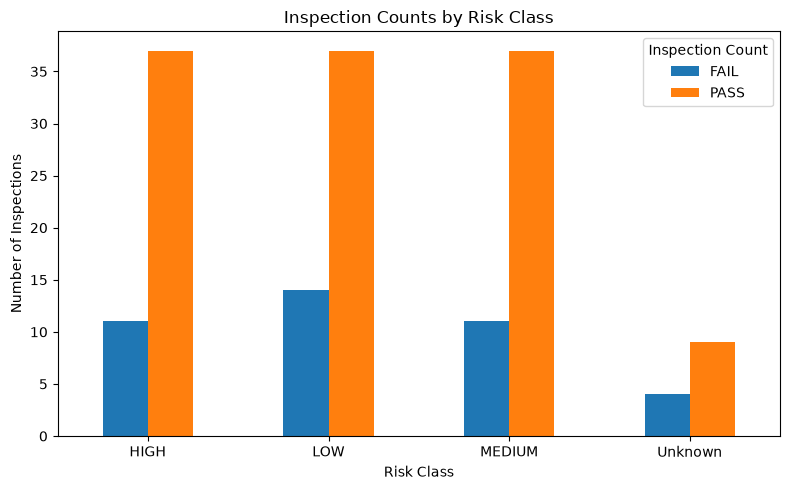

In [245]:
# Risk result count: pd.crosstab() calculate the combined frequencies of two categorical variables
# Records where the Risk field is missing should be displayed separately.
risk_result_counts = pd.crosstab(food["Risk"].fillna("Unknown"), food["Result"])

risk_result_counts.plot(kind="bar", stacked=False, figsize=(8, 5))

plt.title("Inspection Counts by Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Number of Inspections")
plt.legend(title="Inspection Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

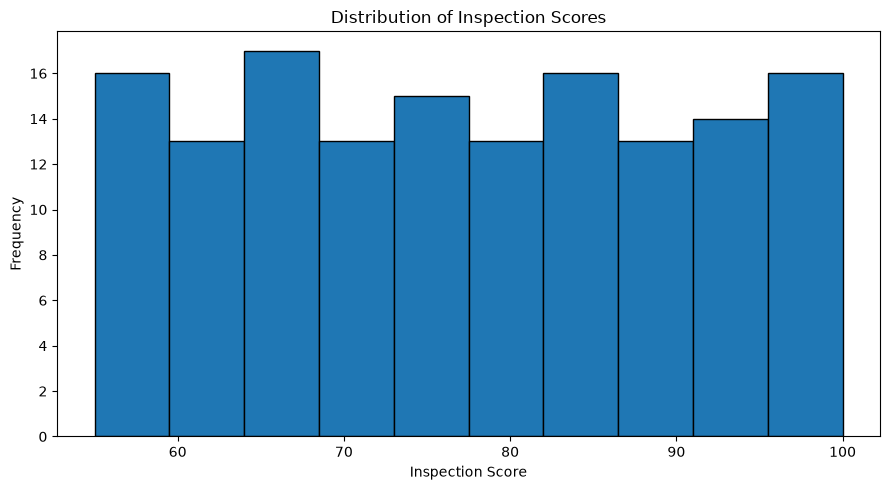

In [246]:
# Exclude missing values when plotting histogram, because it can only display valid values
# Y axis represents the number of records in each interval.
plt.figure(figsize=(9, 5))

plt.hist(food["Inspection Score"].dropna(), bins=10, edgecolor="black")

plt.title("Distribution of Inspection Scores")
plt.xlabel("Inspection Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

- 1e.  Explain two potential risks associated with (i) deleting inspection records containing 
missing values and (ii) filling missing AKA Name values using DBA Name. How might these 
operations affect the accuracy or interpretation of the cleaned dataset?

     - (i) It'll lose the records contain some of useful information, for example, the Inspection Score field for a record is missing, but the Result is Fail. If we delete the entire row, we'll lose this failed inspection record. This also cause a second potential risk: biased results.

    - (ii) There are two risks. One is accuracy. For example, if they have other aliases. The second is that it may mislead the interpretation of the data. For example, users might assume this is the raw data.

Question 2: Numerical preprocessing and visualisation
- 2a. Load product_measurements.csv; inspect missing values and describe the original 
distributions of Droplet Area and Droplet Count using descriptive statistics and plots.

In [247]:
# Load data
product = pd.read_csv('product_measurements.csv')

# Dimension and info
print("Shape:", product.shape)
product.info()


Shape: (120, 7)
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sample ID      120 non-null    str    
 1   Batch          120 non-null    str    
 2   Droplet Area   114 non-null    float64
 3   Droplet Count  120 non-null    int64  
 4   Viscosity      115 non-null    float64
 5   pH             120 non-null    float64
 6   Product Type   120 non-null    str    
dtypes: float64(3), int64(1), str(3)
memory usage: 6.7 KB


In [248]:
# Check for Missing Values
features = ["Droplet Area", "Droplet Count"]
print(product[features].isna().sum())
print(product[features].isna().mean() * 100)  # percentage

Droplet Area     6
Droplet Count    0
dtype: int64
Droplet Area     5.0
Droplet Count    0.0
dtype: float64


In [249]:
# Descriptive Statistics
print(product[features].describe())

       Droplet Area  Droplet Count
count    114.000000     120.000000
mean      40.028509     214.225000
std       33.628241     124.817814
min       19.000000     131.000000
25%       28.805000     171.750000
50%       35.825000     204.500000
75%       44.022500     237.250000
max      332.990000    1500.000000


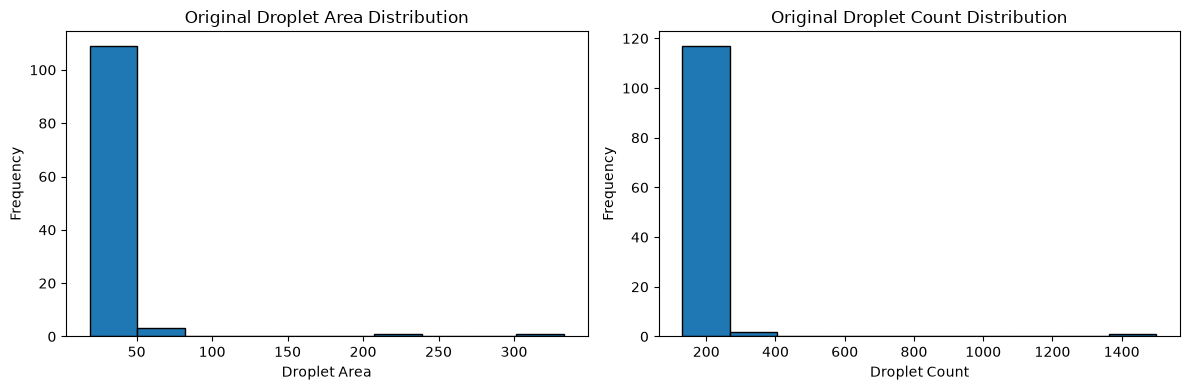

In [250]:
# Plotting Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(product["Droplet Area"].dropna(), bins=10, edgecolor="black")
axes[0].set_title("Original Droplet Area Distribution")
axes[0].set_xlabel("Droplet Area")
axes[0].set_ylabel("Frequency")

axes[1].hist(product["Droplet Count"].dropna(), bins=10, edgecolor="black")
axes[1].set_title("Original Droplet Count Distribution")
axes[1].set_xlabel("Droplet Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Both features show skewed distributions, with most observations concentrated at lower values, contain potential extreme observations, particularly the maximum Droplet Area and Droplet Count values. These extreme observations may affect scaling, especially Min-Max normalisation, because the minimum and maximum determine the scaling range.


- 2b. Droplet Area has 6 missing values, based on my research and understanding, I chose median to fill the missing value because it is generally less susceptible to the influence of outliers than the mean

- 2c.  Generate side-by-side distribution plots (histograms or KDE plots) for original, Z-score 
and Min-Max values for each of the two features. Use clear axes and legends.

- 2d. Calculate or report the minimum, maximum, mean and standard deviation of the two 
scaled features and interpret the results.

In [251]:
# Import library
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Copy data and imputing missing values with the median
product_process = product[features].copy()
imputer = SimpleImputer(strategy="median")
product_process[features] = imputer.fit_transform(product_process[features])

In [252]:
# Question 2: 2b & 2d
#  Z-score standardisation 
z_scaler = StandardScaler()
z_scaled = z_scaler.fit_transform(product_process[features])

# check result
z_product = pd.DataFrame(z_scaled, columns=features, index=product_process.index)
print("Z-score summary:", "\n", z_product.agg(["min", "max", "mean", "std"]))

Z-score summary: 
       Droplet Area  Droplet Count
min  -6.377084e-01  -6.695675e-01
max   8.980451e+00   1.034441e+01
mean -2.368476e-16   4.440892e-17
std   1.004193e+00   1.004193e+00


In [253]:
#  Min-Max normalisation
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(product_process[features])

# check result
minmax_df = pd.DataFrame(minmax_scaled, columns=features, index=product_process.index)
print()
print("Min-Max summary:", "\n", minmax_df.agg(["min", "max", "mean", "std"]))


Min-Max summary: 
       Droplet Area  Droplet Count
min       0.000000       0.000000
max       1.000000       1.000000
mean      0.066303       0.060793
std       0.104406       0.091174


    * Z-score: Both features have means approximately equal to 0 and standard deviations of approximately 1, confirming successful standardisation. The maximum values (8.98 for Droplet Area and 10.34 for Droplet Count) indicate potential extreme observations.
    * Min-Max: Both features have minimum values of 0 and maximum values of 1, confirming successful normalisation. Their low means (0.066 and 0.061) and standard deviations suggest most values are concentrated near the lower end of the range, likely due to extreme values
    * Overall: Both methods change the scale but preserve the distribution’s general shape. Min-Max scaling is particularly affected by extreme values because it uses the minimum and maximum.

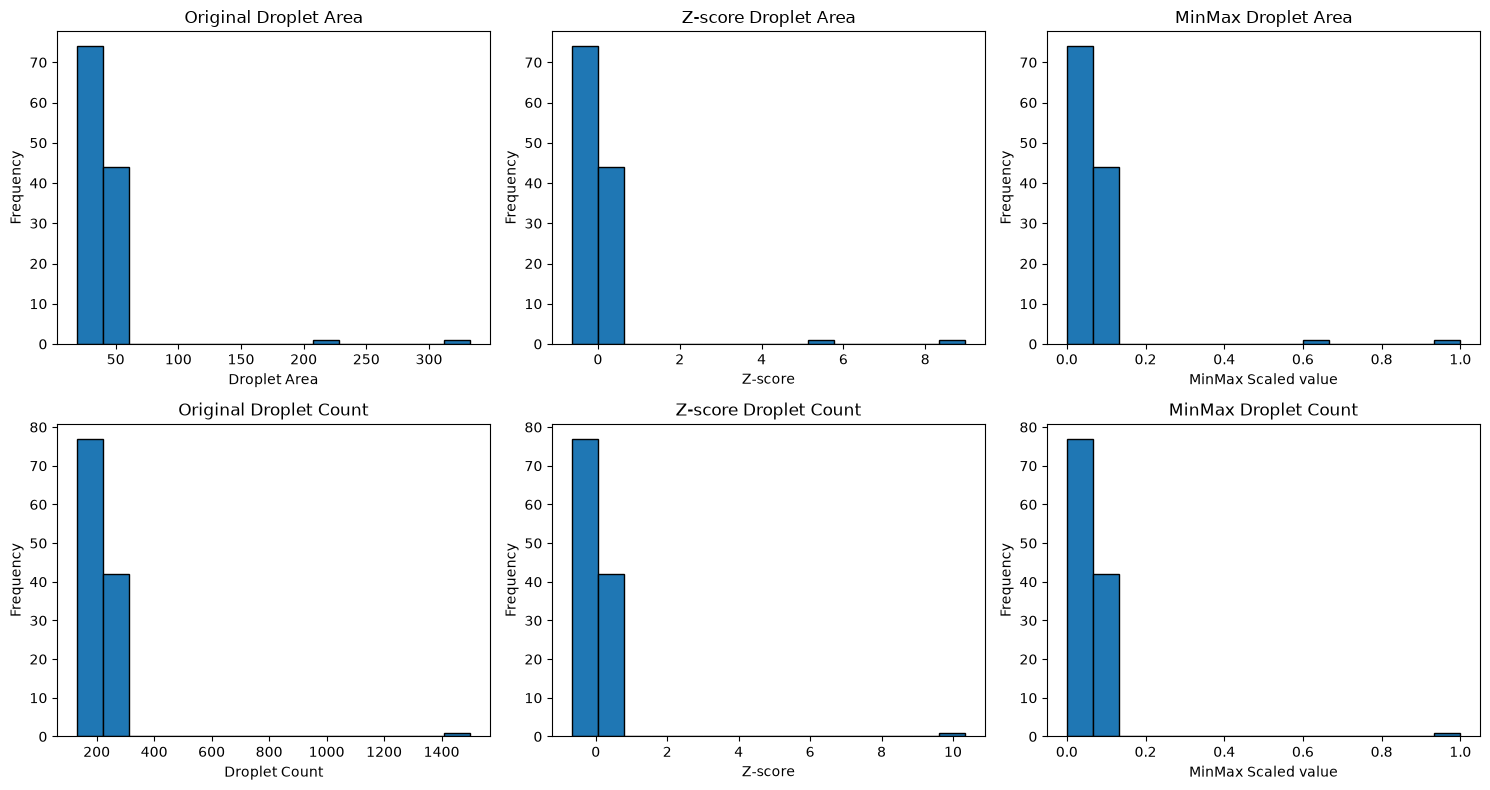

In [254]:
# Question 2: 2c
# Create 2 rows & 3 columns of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feature in enumerate(features):

    # Original data (after median imputation)
    axes[i, 0].hist(product_process[feature], bins=15, edgecolor="black")
    axes[i, 0].set_title(f"Original {feature}")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Frequency")

    # Z-score standardisation
    axes[i, 1].hist(z_product[feature], bins=15, edgecolor="black")
    axes[i, 1].set_title(f"Z-score {feature}")
    axes[i, 1].set_xlabel("Z-score")
    axes[i, 1].set_ylabel("Frequency")

    # Min-Max normalisation
    axes[i, 2].hist(minmax_df[feature], bins=15, edgecolor="black")
    axes[i, 2].set_title(f"MinMax {feature}")
    axes[i, 2].set_xlabel("MinMax Scaled value")
    axes[i, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

- 2e.  Identify extreme observations from the original plots and explain how they affect Min-Max scaled values. Do not remove outliers automatically.

    * The original histograms show potential extreme observations in both features. from descriptive statistics result, Droplet Area has unusually high values, with a maximum of 332.99, while Droplet Count has an extreme maximum of 1,500. These values affect Min Max scaling because the minimum and maximum determine the scaling range. Consequently, most observations are compressed into a narrow range near 0, reducing the visible differences between typical values. These potential outliers should not be removed automatically, as they may represent valid observations.

Question 3 — Image transformations and augmentation

- 3a.  Load synthetic_droplets_1.png and display its original dimensions. Apply Resize, 
CenterCrop and Grayscale, showing each output and its resulting dimensions.

Dimension: (640, 480)


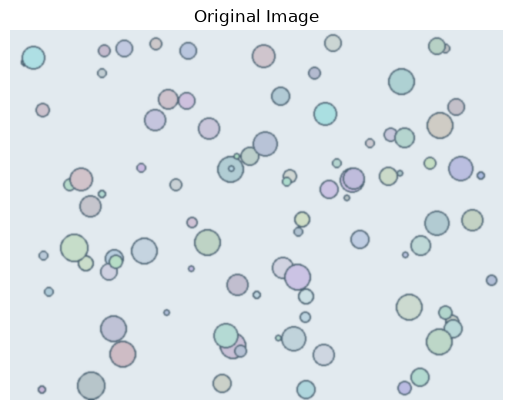

In [255]:
# Load image
image = Image.open('synthetic_droplets_1.png')

print("Dimension:", image.size)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [256]:
# import library
from torchvision import transforms

# apply transform
resize_transform = transforms.Resize((126, 126))
crop_transform = transforms.CenterCrop((100, 100))
gray_transform = transforms.Grayscale()

resized = resize_transform(image)
cropped = crop_transform(image)
grayscale = gray_transform(image)

print("Original:", image.size)
print("Resized:", resized.size)
print("CenterCrop:", cropped.size)
print("Grayscale:", grayscale.size)

Original: (640, 480)
Resized: (126, 126)
CenterCrop: (100, 100)
Grayscale: (640, 480)


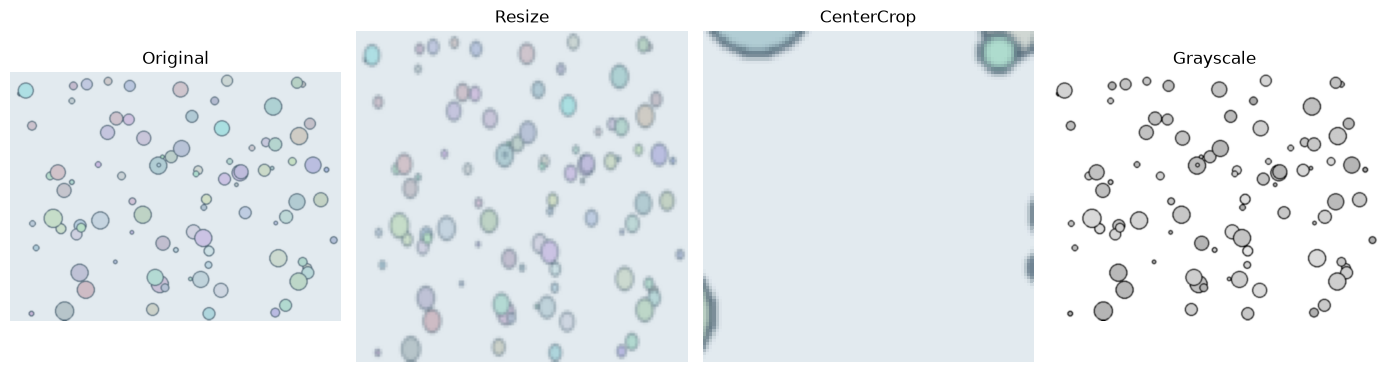

In [257]:
# print images
images = [image, resized, cropped, grayscale]
titles = ["Original", "Resize", "CenterCrop", "Grayscale"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

- 3b. Apply RandomRotation, RandomHorizontalFlip, GaussianBlur and ColorJitter using 
torchvision transforms. Display the original and transformed images in a labelled grid.

In [258]:
# RandomRotation
rotation = transforms.RandomRotation(degrees=45)
# RandomHorizontalFlip
horizontal_flip = transforms.RandomHorizontalFlip(p=0.5)
# GaussianBlur
blur = transforms.GaussianBlur(kernel_size=5, sigma=3.0)
# ColorJitter
color_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)

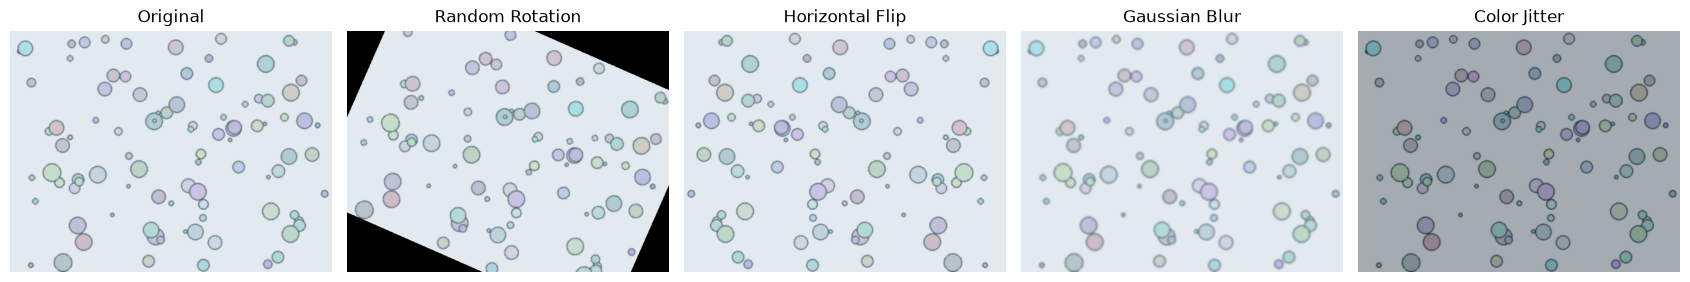

In [259]:
# print images
transforms_list = [
    ("Original", None),
    ("Random Rotation", rotation),
    ("Horizontal Flip", horizontal_flip),
    ("Gaussian Blur", blur),
    ("Color Jitter", color_jitter)
]

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

for ax, (title, transform) in zip(axes, transforms_list):
    if transform is None:
        transformed_image = image
    else:
        transformed_image = transform(image)

    ax.imshow(transformed_image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

- 3c. Apply one random transform at least four times. Explain why repeated calls may give 
different results and show the outputs

    * The same original image is transformed four times. Each call randomly samples a rotation angle within the specified range (degrees between-35, 35). Repeated applications can produce different outputs, demonstrating the stochastic nature of random image augmentation.

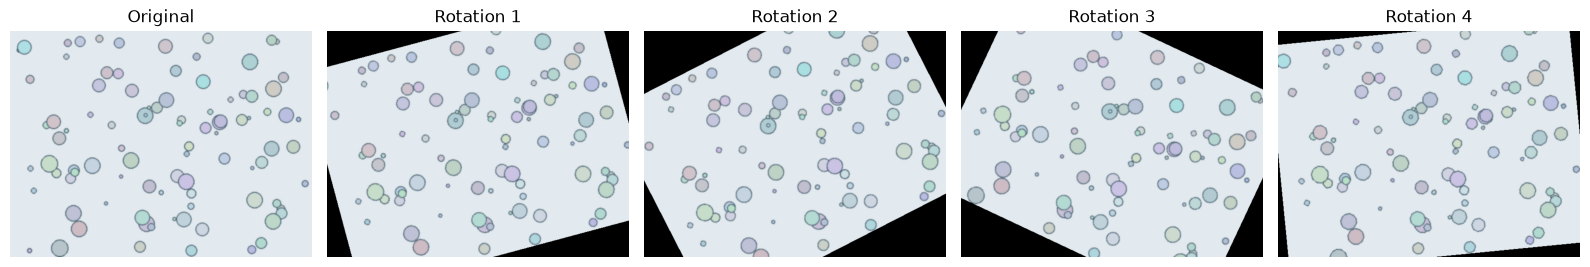

In [260]:
# Define one random transformation
rotation = transforms.RandomRotation(degrees=35)

# Apply it four times to the same original image
results = [rotation(image) for _ in range(4)]

# Display original and four transformed outputs
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

for i, img in enumerate(results):
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"Rotation {i + 1}")
    axes[i + 1].axis("off")


plt.tight_layout()
plt.show()

- 3d. Compare the visual impact of GaussianBlur and cropping on apparent droplet 
boundaries or the visible number of droplets.

    * GaussianBlur primarily affects image sharpness，droplets are not usually removed directly, but small droplets may be harder to identify; CenterCrop directly changes the visible area of the image, it may directly remove droplets outside the cropped area.

- 3e. Explain two reasons why a transformation suitable for general image augmentation 
may be unsuitable when measuring droplet characteristics.

    * they can change droplet size or remove droplets through resizing and cropping
    * they reduce boundary clarity through blurring or changes in brightness and contrast, leading to inaccurate measurements of droplet area and count

Question 4: Text processing and sentiment analysis 

- 4a.  Load skincare_reviews.csv. Define a Python text-cleaning function using regular 
expressions and lowercasing, and show at least six before/after examples.

In [261]:
# Load data
review = pd.read_csv('skincare_reviews.csv')

print(review.head(6))
print("\nShape:", review.shape)

  Review ID Product Category                                          Review
0      R001            Cream  The cream feels wonderful and my skin is soft!
1      R002            Cream               I do not like the greasy texture.
2      R003           Lotion                   The lotion is not bad at all.
3      R004            Cream    Absolutely fantastic moisturiser, I love it!
4      R005           Lotion                    It is okay, nothing special.
5      R006           Lotion        The bottle leaked and I am disappointed.

Shape: (100, 3)


In [262]:
# Use re.sub() to remove non alphabetic characters, then convert the text to lowercase
import re


def preprocess_text(text):
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    return text

review["review_cleaned"] = review["Review"].apply(preprocess_text)

# Display six examples
print(review[["Review", "review_cleaned"]].head(6).to_string(index=False))

                                        Review                                review_cleaned
The cream feels wonderful and my skin is soft! the cream feels wonderful and my skin is soft
             I do not like the greasy texture.              i do not like the greasy texture
                 The lotion is not bad at all.                  the lotion is not bad at all
  Absolutely fantastic moisturiser, I love it!    absolutely fantastic moisturiser i love it
                  It is okay, nothing special.                    it is okay nothing special
      The bottle leaked and I am disappointed.       the bottle leaked and i am disappointed


- 4b. Tokenise reviews and apply Porter stemming and WordNet lemmatisation separately. Compare outputs for at least five selected reviews, highlighting differences.
    * word_tokenize(): Splits comments into tokens.
    * PorterStemmer(): Performs stemming, which may result in incomplete word stems.
    * WordNetLemmatizer(): Performs lemmatization, typically attempting to preserve valid word forms.

In [263]:
# Function to apply stemming
def apply_stemming(text):
    if isinstance(text, str):
        ps = PorterStemmer()
        words = word_tokenize(text)
        stemmed_words = [ps.stem(word) for word in words]
        return " ".join(stemmed_words)
    else:
        return ""

# Function to apply lemmatization
def apply_lemmatization(text):
    if isinstance(text, str):
        lemmatizer = WordNetLemmatizer()
        words = word_tokenize(text)
        lemmatized_words = [
            lemmatizer.lemmatize(word) for word in words
        ]
        return " ".join(lemmatized_words)
    else:
        return ""

In [264]:
# Apply stemming and lemmatization
review["Stemmed Review"] = review["review_cleaned"].apply(apply_stemming)
review["Lemmatized Review"] = review["review_cleaned"].apply(apply_lemmatization)

# Display 5 examples
display(
    review[["Review", "Stemmed Review", "Lemmatized Review"]].head(5)
)

,Review,Stemmed Review,Lemmatized Review
0,The cream feels wonderful and my skin is soft!,the cream feel wonder and my skin is soft,the cream feel wonderful and my skin is soft
1,I do not like the greasy texture.,i do not like the greasi textur,i do not like the greasy texture
2,The lotion is not bad at all.,the lotion is not bad at all,the lotion is not bad at all
3,"Absolutely fantastic moisturiser, I love it!",absolut fantast moisturis i love it,absolutely fantastic moisturiser i love it
4,"It is okay, nothing special.",it is okay noth special,it is okay nothing special


* Stemming removes or reduces word endings using a rule-based process. The resulting stems may not be complete English words, such as greasi, textur, and absolut.
* Lemmatisation generally produces recognisable words, such as greasy, texture, and absolutely.
* Stemming is more aggressive in shortening words, while lemmatisation tends to preserve meaningful word forms.


- 4c. Use NLTK VADER to calculate compound sentiment scores on original reviews, cleaned reviews and lemmatised reviews. Present the results in a DataFrame and compare their distributions using a suitable plot.

In [265]:
# NLTK is missing the VADER sentiment lexicon vader_lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ldldld\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [266]:
# Sentiment Analysis
sia = SentimentIntensityAnalyzer()

def sentiment_analysis(text):
    sentiment_score = sia.polarity_scores(text)
    return sentiment_score["compound"]

In [267]:
# Sentiment scores for original reviews
review["Original Sentiment"] = review["Review"].apply(sentiment_analysis)

# Sentiment scores for cleaned reviews
review["Cleaned Sentiment"] = review["review_cleaned"].apply(sentiment_analysis)

# Sentiment scores for lemmatized reviews
review["Lemmatized Sentiment"] = review["Lemmatized Review"].apply(sentiment_analysis)

# Display the results
display(
    review[
        [
            "Review",
            "Original Sentiment",
            "Cleaned Sentiment",
            "Lemmatized Sentiment"
        ]
    ].head(10)
)

,Review,Original Sentiment,Cleaned Sentiment,Lemmatized Sentiment
0,The cream feels wonderful and my skin is soft!,0.6114,0.5719,0.5719
1,I do not like the greasy texture.,-0.2755,-0.2755,-0.2755
2,The lotion is not bad at all.,0.4310,0.4310,0.4310
3,"Absolutely fantastic moisturiser, I love it!",0.8641,0.8540,0.8540
4,"It is okay, nothing special.",-0.0920,-0.0920,-0.0920
5,The bottle leaked and I am disappointed.,-0.6597,-0.6597,-0.6597
6,Not good: sticky and unpleasant.,-0.6711,-0.6711,-0.6711
7,I expected better results.,0.4404,0.4404,0.4404
8,The fragrance is lovely but the pump is broken.,-0.4118,-0.4118,-0.4118
9,The cream is lightweight and works well.,0.2732,0.2732,0.2732


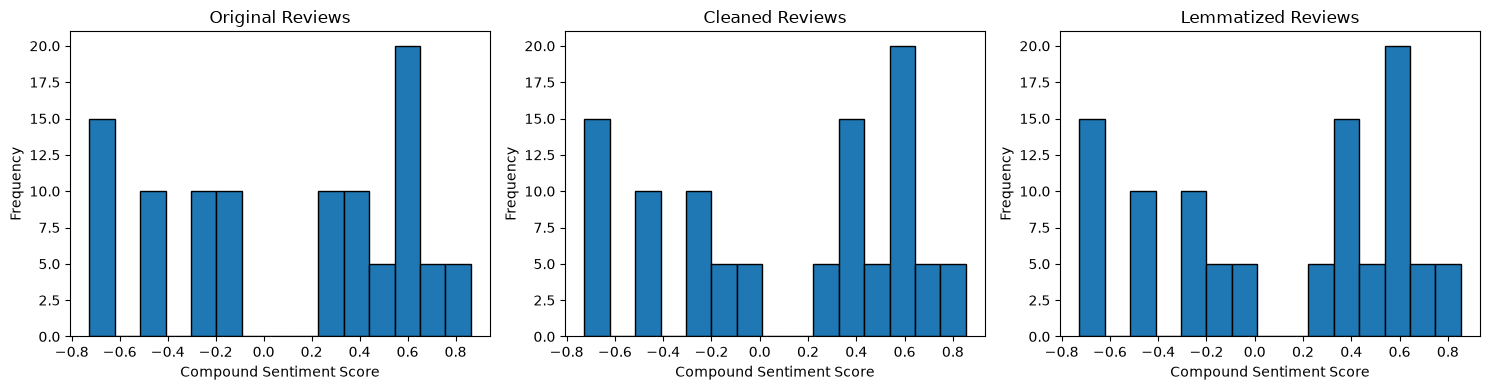

In [268]:
# Plot the distributions of sentiment scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(review["Original Sentiment"].dropna(), bins=15, edgecolor="black")
axes[0].set_title("Original Reviews")
axes[0].set_xlabel("Compound Sentiment Score")
axes[0].set_ylabel("Frequency")

axes[1].hist(review["Cleaned Sentiment"].dropna(), bins=15, edgecolor="black")
axes[1].set_title("Cleaned Reviews")
axes[1].set_xlabel("Compound Sentiment Score")
axes[1].set_ylabel("Frequency")

axes[2].hist(review["Lemmatized Sentiment"].dropna(), bins=15, edgecolor="black")
axes[2].set_title("Lemmatized Reviews")
axes[2].set_xlabel("Compound Sentiment Score")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

* Most sentiment scores are similar across the original, cleaned, and lemmatised reviews
* The cleaned and lemmatised distributions show some changes, particularly in the positive score range. This suggests that removing punctuation and changing word forms can affect some vader sentiment scores, although the overall distribution remains similar.

- 4d. Select three reviews where preprocessing changes the score (or, if no changes occur, 
three with informative unchanged scores). Explain the observed behaviour, including the role of 
punctuation or negation where relevant.

In [271]:
# Calculate sentiment score differences
review["Cleaned Difference"] = (review["Cleaned Sentiment"] - review["Original Sentiment"]).abs()
review["Lemmatized Difference"] = (review["Lemmatized Sentiment"] - review["Original Sentiment"]).abs()

# Remove duplicate reviews
unique_review = review.drop_duplicates(subset=["Review"]).copy()

# Display the 10 reviews with the largest sentiment changes
display(
    unique_review[
        [
            "Review",
            "Original Sentiment",
            "Cleaned Sentiment",
            "Lemmatized Sentiment",
            "Cleaned Difference",
            "Lemmatized Difference"
        ]
    ]
    .sort_values(
        by=["Cleaned Difference", "Lemmatized Difference"],
        ascending=False
    )
    .head(10)
)

,Review,Original Sentiment,Cleaned Sentiment,Lemmatized Sentiment,Cleaned Difference,Lemmatized Difference
17,No irritation and great hydration!,-0.1759,-0.1027,-0.1027,0.0732,0.0732
0,The cream feels wonderful and my skin is soft!,0.6114,0.5719,0.5719,0.0395,0.0395
60,The moisturiser feels wonderful and my skin is...,0.6114,0.5719,0.5719,0.0395,0.0395
19,Amazing quality! Would purchase again.,0.6239,0.5859,0.5859,0.0380,0.0380
3,"Absolutely fantastic moisturiser, I love it!",0.8641,0.8540,0.8540,0.0101,0.0101
1,I do not like the greasy texture.,-0.2755,-0.2755,-0.2755,0.0000,0.0000
2,The lotion is not bad at all.,0.4310,0.4310,0.4310,0.0000,0.0000
4,"It is okay, nothing special.",-0.0920,-0.0920,-0.0920,0.0000,0.0000
5,The bottle leaked and I am disappointed.,-0.6597,-0.6597,-0.6597,0.0000,0.0000
6,Not good: sticky and unpleasant.,-0.6711,-0.6711,-0.6711,0.0000,0.0000


 * review 17: Score changes from -0.1759 to -0.1027. Removing the exclamation mark changes the vader score slightly. The negative score may also reflect how vader evaluates individual words in the sentence.
 * review 0: core changes from 0.6114 to 0.5719. Removing punctuation reduces the score slightly, although the review remains positive.
 * review 1: Score remains -0.2755. The score is unchanged because the words, including the negation “not”, remain intact after cleaning.

- 4e.  State whether the preprocessing method producing the shortest text is necessarily 
best for sentiment analysis, with one evidence-based example.

    * No, shorter text does not always improve sentiment analysis. Removing punctuation can change vader sentiment scores slightly, as seen in Review 0, where the score decreased from 0.6114 to 0.5719. However, Review 1 remained unchanged at -0.2755 because the important words, including “not”, were preserved. Therefore, text preprocessing may affect sentiment scores, but shorter text does not necessarily produce more accurate results.